# Assignment 1: Introduction to language modeling

### ⚙  Task 0.1: Setting up the environment

In [ ]:
import nltk
from collections import Counter
import os

import torch
from torch import nn
from transformers import PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput
import numpy as np

/Users/natalija.glisovic/Documents/phd_course_work/Deep Learning for NLP/labs/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Tokenization

### ⚙  Task 1.1: Using NLTK or SpaCy for word splitting

In [2]:
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Example
word_tokenize("Let's test!!")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/natalija.glisovic/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['Let', "'s", 'test', '!', '!']

### 🎓  Task 1.2: Building the vocabulary

In [3]:
def lowercase_tokenizer(text):
    """Split text into word tokens and convert all to lowercase."""
    return [t.lower() for t in nltk.word_tokenize(text)]


def build_tokenizer(train_file, tokenize_fun=lowercase_tokenizer, max_voc_size=None, model_max_length=None,
                    pad_token='<PAD>', unk_token='<UNK>', bos_token='<BOS>', eos_token='<EOS>'):
    """Build a tokenizer from the given training file.

    Reads every non-empty line (= one Wikipedia paragraph), counts token
    frequencies, keeps at most max_voc_size tokens (most frequent first),
    and returns a ready-to-use A1Tokenizer.

    Args:
         train_file:        Path to the training text file.
         tokenize_fun:      Function that maps a raw string to a list of string tokens.
         max_voc_size:      Maximum vocabulary size (including the 4 special tokens).
         model_max_length:  Truncate sequences longer than this many tokens.
         pad_token:         String used for padding shorter sequences.
         unk_token:         String used for out-of-vocabulary tokens.
         bos_token:         String inserted at the beginning of each sequence.
         eos_token:         String inserted at the end of each sequence.
    """

    # Count how often each token appears across all training paragraphs.
    # Counter gives us a dict-like object: token -> frequency.
    token_counts = Counter()
    with open(train_file, encoding='utf-8') as f:
        for line in f:
            line = line.strip()      # remove leading/trailing whitespace and newline
            if line:                 # skip empty lines (blank paragraphs)
                token_counts.update(tokenize_fun(line))

    # Reserve the first 4 integer IDs for special tokens.
    # Fill the remaining slots with the most frequent real words.
    special_tokens = [bos_token, eos_token, unk_token, pad_token]
    n_real = (max_voc_size - len(special_tokens)) if max_voc_size else len(token_counts)
    real_tokens = [tok for tok, _ in token_counts.most_common(n_real)]

    # Final ordered list: special tokens get IDs 0-3, real words follow
    vocab = special_tokens + real_tokens

    # Build the two lookup tables
    str_to_int = {tok: idx for idx, tok in enumerate(vocab)}
    int_to_str  = {idx: tok for tok, idx in str_to_int.items()}

    return A1Tokenizer(
        str_to_int       = str_to_int,
        int_to_str       = int_to_str,
        tokenize_fun     = tokenize_fun,
        bos_token        = bos_token,
        eos_token        = eos_token,
        unk_token        = unk_token,
        pad_token        = pad_token,
        model_max_length = model_max_length,
    )

In [4]:
max_voc_size = 10_000   # quite small size

# 1: apply the tokenizer to all paragraphs (train + val) 
data_dir = os.path.join(os.path.dirname(os.path.abspath('assignment_1.ipynb')), 'a1_1')

def tokenize_file(filepath):
    """Return a list of token lists, one per non-empty paragraph."""
    paragraphs = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()   # remove trailing newline / whitespace
            if line:              # skip blank lines
                paragraphs.append(lowercase_tokenizer(line))   # lowercase all from tokenizer
    return paragraphs

train_paragraphs = tokenize_file(os.path.join(data_dir, 'train.txt'))
val_paragraphs   = tokenize_file(os.path.join(data_dir, 'val.txt'))

print(f"Training paragraphs  : {len(train_paragraphs)}")
print(f"Validation paragraphs: {len(val_paragraphs)}")
print(f"First train paragraph (first 10 tokens): {train_paragraphs[0][:10]}")

# --- Step 2 & 3: build vocabulary using build_tokenizer from the skeleton ---
# build_tokenizer reads the training file, counts token frequencies with Counter,
# reserves 4 slots for special symbols, and fills the rest with the most
# frequent real words up to max_voc_size.
# Special token names match the assignment example (BEGINNING / END / UNKNOWN / PAD).

tokenizer = build_tokenizer(
    train_file       = os.path.join(data_dir, 'train.txt'),
    max_voc_size     = max_voc_size,
    model_max_length = 512,
    bos_token        = 'BEGINNING',
    eos_token        = 'END',
    unk_token        = 'UNKNOWN',
    pad_token        = 'PAD',
)

# pull out the two lookup tables for inspection and sanity checks
str_to_int = tokenizer.str_to_int   # word  -> integer
int_to_str = tokenizer.int_to_str   # integer -> word

print(f"\nVocabulary size: {len(tokenizer)}")
print("First 10 entries:", list(str_to_int.items())[:10])
# Expected: {'BEGINNING': 0, 'END': 1, 'UNKNOWN': 2, 'PAD': 3, 'the': 4, ...}

# Sanity checks
SPECIAL_TOKENS = ['BEGINNING', 'END', 'UNKNOWN', 'PAD']

# vocab size does not exceed max_voc_size
assert len(tokenizer) <= max_voc_size, "vocab exceeds max_voc_size!"
print(f"ok vocab size {len(tokenizer)} <= max_voc_size {max_voc_size}")

# all 4 special symbols exist and have distinct integer IDs
for sp in SPECIAL_TOKENS:
    assert sp in str_to_int, f"special token '{sp}' missing!"
special_ids = [str_to_int[sp] for sp in SPECIAL_TOKENS]
assert len(set(special_ids)) == len(SPECIAL_TOKENS), "special token IDs are not unique!"
print(f"ok special tokens: { {sp: str_to_int[sp] for sp in SPECIAL_TOKENS} }")

# special tokens do not coincide with any real word in the training set
# (build_tokenizer uses strings like 'BEGINNING' that cannot appear as
#  lowercase tokenized words, so this should always pass)
for sp in SPECIAL_TOKENS:
    assert sp not in tokenizer.str_to_int or str_to_int[sp] < len(SPECIAL_TOKENS), \
        f"Special token '{sp}' clashes with a real word!"
print("[OK] Special tokens do not coincide with real words")

# frequent words are in the vocab; rare words are excluded
common_words = ['the', 'and', 'of', 'in', 'a']
rare_words   = ['cuboidal', 'epiglottis']

for w in common_words:
    assert w in str_to_int, f"common word '{w}' missing from vocab!"
print(f"ok common words in vocab: {common_words}")

for w in rare_words:
    if w not in str_to_int:
        print(f"ok rare word '{w}' correctly excluded from vocab")
    else:
        print(f"rare word '{w}' made it into the vocab")

#  map test word to an integer and then back to the original test word using the inverse mapping to ensure nothing lost or overwritten
test_word = 'the'
recovered = int_to_str[str_to_int[test_word]]
assert recovered == test_word, "Round-trip mapping failed!"
print(f"[OK] Round-trip: '{test_word}' -> {str_to_int[test_word]} -> '{recovered}'")

Training paragraphs  : 147059
Validation paragraphs: 17874
First train paragraph (first 10 tokens): ['anatomy']

Vocabulary size: 10000
First 10 entries: [('BEGINNING', 0), ('END', 1), ('UNKNOWN', 2), ('PAD', 3), ('the', 4), (',', 5), ('.', 6), ('of', 7), ('and', 8), ('in', 9)]
ok vocab size 10000 <= max_voc_size 10000
ok special tokens: {'BEGINNING': 0, 'END': 1, 'UNKNOWN': 2, 'PAD': 3}
[OK] Special tokens do not coincide with real words
ok common words in vocab: ['the', 'and', 'of', 'in', 'a']
ok rare word 'cuboidal' correctly excluded from vocab
ok rare word 'epiglottis' correctly excluded from vocab
[OK] Round-trip: 'the' -> 4 -> 'the'


### ⚙  Task 1.3: Implementing a HuggingFace-like Tokenizer

In [5]:
tokenizer = build_tokenizer(
    'a1_1/train.txt',
    max_voc_size=10_000,
    model_max_length=512,
)

test_texts = ['This is a test.', 'Another test.']
out = tokenizer(test_texts, return_tensors='pt', padding=True, truncation=True)
print(out)

# Check: first token of every row should be BOS
assert out['input_ids'][0, 0].item() == tokenizer.bos_token_id
assert out['input_ids'][1, 0].item() == tokenizer.bos_token_id

# Save and reload
tokenizer.save('a1_1/tokenizer.pkl')
tokenizer2 = A1Tokenizer.from_file('a1_1/tokenizer.pkl')
assert len(tokenizer2) == len(tokenizer)
print("Save/load OK")

{'input_ids': tensor([[  0,  35,  14,  11, 975,   6,   1],
        [  0, 155, 975,   6,   1,   3,   3]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0, 0]])}
Save/load OK


## Part 2: Loading the text files and creating batches

### ⚙  Task 2.1: Loading the texts

In [6]:
from datasets import load_dataset
dataset = load_dataset('text', data_files={'train': 'a1_1/train.txt', 'val': 'a1_1/val.txt'})

In [7]:
dataset = dataset.filter(lambda x: x['text'].strip() != '')

In [8]:
#from torch.utils.data import Subset
#for sec in ['train', 'val']:
    #dataset[sec] = Subset(dataset[sec], range(1000))

### ⚙  Task 2.2: Iterating through the datasets

In [9]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    texts = [item['text'] for item in batch]
    return tokenizer(texts, truncation=True, padding=True, return_tensors='pt')

dl_train = DataLoader(dataset['train'], batch_size=32, shuffle=True,  collate_fn=collate_fn)
dl_val   = DataLoader(dataset['val'],   batch_size=32, shuffle=False, collate_fn=collate_fn)

# Sanity check
for batch in dl_train:
    print(batch)
    break

{'input_ids': tensor([[   0,  519,    5,  ...,    3,    3,    3],
        [   0, 2307, 1360,  ...,    3,    3,    3],
        [   0,  155,  229,  ...,    3,    3,    3],
        ...,
        [   0,    2, 1583,  ...,    3,    3,    3],
        [   0,    4,   56,  ...,    3,    3,    3],
        [   0,   27, 5787,  ...,    3,    3,    3]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}


## Part 3: Defining the language model neural network and computing the loss

### 🎓  Task 3.1: Setting up the network

In [10]:
class A1RNNModelConfig(PretrainedConfig):
    """Stores the hyperparameters that define the RNN language model architecture."""

    def __init__(self, vocab_size, embedding_size, hidden_size, **kwargs):
        super().__init__(**kwargs)   # pass any extra HuggingFace config args upward
        self.vocab_size      = vocab_size       # number of tokens in the vocabulary
        self.hidden_size     = hidden_size      # size of the GRU hidden state
        self.embedding_size  = embedding_size   # size of the token embedding vectors


class A1RNNModel(PreTrainedModel):
    """RNN-based autoregressive language model.

    Architecture:
        token IDs  →  Embedding  →  GRU  →  Linear (unembedding)  →  logits
    """
    config_class = A1RNNModelConfig

    def __init__(self, config):
        super().__init__(config)
        self.embedding   = nn.Embedding(config.vocab_size, config.embedding_size) #lookup table, integer token id maps to floating point vector of size emb. so input batch, seq.leng = batch, seq-leng, emb.size
        self.rnn         = nn.GRU(config.embedding_size, config.hidden_size, batch_first=True) #batch size true means tensor arranged b (batch), n(seq length), e(embedding dim), otherwise NBE
        self.unembedding = nn.Linear(config.hidden_size, config.vocab_size) #plain linear player projects RNN hidden state each pos. into logit (score) for every word in vocab, opposite of emb. so we know next word
        self.loss_func   = torch.nn.CrossEntropyLoss(ignore_index=-100) #padding positions replace by -100 by trainer so ignore those positions


    def forward(self, input_ids, labels=None):
        """Forward pass of the language model.

        Args:
          input_ids:  2D integer tensor (batch, seq_len) of token IDs.
          labels:     2D integer tensor (batch, seq_len), same as input_ids
                      but with padding positions replaced by -100.

        Returns:
          CausalLMOutput with:
            logits:  (batch, seq_len, vocab_size) — raw next-token scores.
            loss:    scalar cross-entropy loss (only computed when labels given).
        """
        # 1.convert token IDs to dense embedding vectors
        embedded        = self.embedding(input_ids)   # (batch, seq_len, embedding_size)- convert token to dense vectors
        # 2. run the GRU; _ is the final hidden state (not needed here)
        rnn_out, _      = self.rnn(embedded)           # (batch, seq_len, hidden_size) #run GRU over whole sequence so hidden state evrry positino
        # 3. project to vocabulary scores at every position
        logits          = self.unembedding(rnn_out)    # (batch, seq_len, vocab_size) #each position hidden state to vocab scores


        loss = None
        if labels is not None:
            # Autoregressive shift: position t predicts position t+1.
            # Drop the last logit (nothing to predict after EOS) and
            # drop the first label (BOS is never a prediction target).
            shift_logits = logits[:, :-1, :].contiguous()   # (batch, seq_len-1, vocab_size)
            shift_labels = labels[:, 1:].contiguous()        # (batch, seq_len-1)

            # Flatten to 2D/1D as required by CrossEntropyLoss
            loss = self.loss_func(
                shift_logits.view(-1, self.config.vocab_size),
                shift_labels.view(-1)
            )

        return CausalLMOutput(logits=logits, loss=loss)

### 🎓  Task 3.2: Computing the loss

In [11]:
config = A1RNNModelConfig(
    vocab_size     = len(tokenizer),   # 10000
    embedding_size = 64, #arbitary values for sanity check
    hidden_size    = 128,
)
model = A1RNNModel(config)

#mainly sanity check to see if model can process input and produce output of correct shape, not training yet

# create a random integer tensor of shape (1, N), values < vocab_size
N = 20
dummy_input = torch.randint(low=0, high=config.vocab_size, size=(1, N)) #ranomdly initialised weights 
print("input shape:", dummy_input.shape)         # should be (1, 20)

# apply the model (no labels so no loss computed)
output = model(dummy_input) #no labels so no loss computed, just get logits

# check output logits shape is (1, N, vocab_size)
print("logits shape:", output.logits.shape)      #should be 1,N, vocab size
assert output.logits.shape == (1, N, config.vocab_size)
print("shape check passed!")

input shape: torch.Size([1, 20])
logits shape: torch.Size([1, 20, 10000])
shape check passed!


## Part 4: Training the model

### 🎓  Task 4.1: Implementing the trainer

In [12]:
class A1Trainer:
    """A minimal Trainer similar to HuggingFace's Trainer class."""

    def __init__(self, model, args, train_dataset, eval_dataset, tokenizer):
        """Set up the trainer.

        Args:
          model:          The A1RNNModel to train.
          args:           TrainingArguments object with all hyperparameters.
          train_dataset:  HuggingFace dataset split used for training.
          eval_dataset:   HuggingFace dataset split used for validation.
          tokenizer:      The A1Tokenizer used to encode raw text.
        """
        self.model         = model
        self.args          = args
        self.train_dataset = train_dataset
        self.eval_dataset  = eval_dataset
        self.tokenizer     = tokenizer

        assert(args.optim == 'adamw_torch')
        assert(args.eval_strategy == 'epoch')

    def select_device(self):
        """Return the best available device (CPU / CUDA GPU / Apple MPS)."""
        if self.args.use_cpu:
            return torch.device('cpu')
        if not self.args.no_cuda and torch.cuda.is_available():
            return torch.device('cuda')
        if torch.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')

    def train(self):
        """Run the full training loop and save the model."""
        args = self.args

        device = self.select_device()
        print('Device:', device)
        self.model.to(device)

        # AdamW optimizer — updates all trainable model parameters each step
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=args.learning_rate)

        # collate_fn: called by DataLoader on each raw batch.
        # Tokenizes the list of paragraph strings and pads them to the same length.
        def collate_fn(batch):
            texts = [item['text'] for item in batch]
            return self.tokenizer(texts, truncation=True, padding=True, return_tensors='pt')

        # Training loader shuffles order every epoch so the model doesn't
        # memorise paragraph order. Validation loader keeps a fixed order.
        train_loader = DataLoader(
            self.train_dataset,
            batch_size  = args.per_device_train_batch_size,
            shuffle     = True,
            collate_fn  = collate_fn,
        )
        val_loader = DataLoader(
            self.eval_dataset,
            batch_size  = args.per_device_eval_batch_size,
            shuffle     = False,
            collate_fn  = collate_fn,
        )

        #,ain training loop
        for epoch in range(args.num_train_epochs):

            #training phase
            self.model.train()   # enable dropout and other training-only behaviours
            total_train_loss = 0

            for batch in train_loader:
                input_ids = batch['input_ids'].to(device) #go over each batch

                # labels are identical to input_ids except padding positions that are replaced with -100 so CrossEntropyLoss ignores them
                labels = input_ids.clone()
                labels[labels == self.tokenizer.pad_token_id] = -100

                # Forward pass: model computes logits and the cross-entropy loss
                output = self.model(input_ids=input_ids, labels=labels)
                loss   = output.loss

                # Backward pass: compute gradients and update weights
                optimizer.zero_grad()   # clear gradients from the previous step
                loss.backward()         # compute new gradients
                optimizer.step()        # update model parameters

                total_train_loss += loss.item()

            avg_train_loss = total_train_loss / len(train_loader)
            print(f'Epoch {epoch+1}/{args.num_train_epochs}  '
                  f'train loss: {avg_train_loss:.4f}  '
                  f'perplexity: {torch.exp(torch.tensor(avg_train_loss)):.2f}')

            # validation phase
            self.model.eval()    # disable dropout etc. to evalate on the validation set
            total_val_loss = 0

            with torch.no_grad():   # no gradients needed — saves memory and time, no need to update weight
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    labels    = input_ids.clone()
                    labels[labels == self.tokenizer.pad_token_id] = -100

                    output = self.model(input_ids=input_ids, labels=labels)
                    total_val_loss += output.loss.item()

            avg_val_loss = total_val_loss / len(val_loader)
            print(f'Epoch {epoch+1}/{args.num_train_epochs}  '
                  f'val loss:   {avg_val_loss:.4f}  '
                  f'perplexity: {torch.exp(torch.tensor(avg_val_loss)):.2f}')

        print(f'Saving to {args.output_dir}.')
        self.model.save_pretrained(args.output_dir)



In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir                  = 'a1_1/model_output',
    num_train_epochs            = 1,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 64,
    learning_rate               = 1e-3,
    eval_strategy               = 'epoch',
    optim                       = 'adamw_torch',
    use_cpu                     = True,   # set False if you have a GPU
)

trainer = A1Trainer(
    model         = model,
    args          = training_args,
    train_dataset = dataset['train'],
    eval_dataset  = dataset['val'],
    tokenizer     = tokenizer,
)

trainer.train()

Device: cpu
Epoch 1/1  train loss: 4.9992  perplexity: 148.30
Epoch 1/1  val loss:   4.6167  perplexity: 101.16
Saving to a1_1/model_output.


TypeError: A1RNNModelConfig.__init__() missing 3 required positional arguments: 'vocab_size', 'embedding_size', and 'hidden_size'

## Part 5: Evaluation and analysis

### ⚙  Task 5.1: Predicting the next word

In [14]:
# 1. Choose some example text and tokenize it
example_text = "She lives in San"
encoded = tokenizer([example_text], truncation=True, padding=False, return_tensors='pt')
input_ids = encoded['input_ids']  # shape: (1, seq_len)

print("Tokenized input:")
print([int_to_str.get(i.item(), '?') for i in input_ids[0]])
# e.g. ['<BOS>', 'she', 'lives', 'in', 'san', '<EOS>']

# 2. Forward pass — no labels needed, just logits
with torch.no_grad():
    output = model(input_ids=input_ids)

logits = output.logits  # shape: (1, seq_len, vocab_size)

# 3. Take logits at the second-to-last position.
#    Our tokenizer appends EOS, so the sequence is [BOS ... last_word EOS].
#    The prediction for "what comes after last_word" lives at position -2.
next_word_logits = logits[0, -2, :]  # shape: (vocab_size,)

# 4. Top-k predictions
k = 10
top_scores, top_indices = torch.topk(next_word_logits, k)

# Convert logits to probabilities with softmax
probs = torch.softmax(next_word_logits, dim=-1)

print(f"\nTop {k} predictions after '{example_text}':")
for rank, (idx, score) in enumerate(zip(top_indices, top_scores), 1):
    word = int_to_str.get(idx.item(), 'UNKNOWN')
    prob = probs[idx].item()
    print(f"  {rank:2}. {word:<15}  logit={score:.2f}  prob={prob:.4f}")

# 5. Single best prediction via argmax
best_idx  = torch.argmax(next_word_logits).item()
best_word = int_to_str.get(best_idx, 'UNKNOWN')
print(f"\nArgmax prediction: '{best_word}'")

Tokenized input:
['BEGINNING', 'she', 'lives', 'in', 'san', 'END']

Top 10 predictions after 'She lives in San':
   1. francisco        logit=9.04  prob=0.2516
   2. diego            logit=8.93  prob=0.2242
   3. UNKNOWN          logit=8.17  prob=0.1046
   4. suu              logit=6.96  prob=0.0312
   5. juan             logit=6.42  prob=0.0182
   6. antonio          logit=5.80  prob=0.0098
   7. and              logit=5.49  prob=0.0072
   8. ,                logit=5.33  prob=0.0061
   9. england          logit=4.99  prob=0.0044
  10. psychology       logit=4.77  prob=0.0035

Argmax prediction: 'francisco'


### 🎓  Task 5.2: Computing the perplexity

Perplexity measures essentially how surprised model is at the next word, e.g. she lives in new.... if high prob = york = low suprise = low perplex and the opposite would be high perplex. better than loss because its easy to interprey, e.g. perplex of 500 means model is as confused as if it had to pick ranomdly from 500 equally likely word each step.

Did in trainer 
total_val_loss += output.loss.item()

output.loss is cross-entory loss for the batch which is the mean of negative log-probabilities of the correct tokens and then item converts it from trnsor to python float. w accumulate across all batches and get 

avg_val_loss = total_val_loss / len(val_loader)

divides by the number of batches to get mean cross-entory loss over validation. that is the  (1/m) * Σ -log P(wi|ci) part of the formula. 

torch.exp(torch.tensor(avg_val_loss)) 

then applies exp to meanb loss and that is perplexity formula - i.e. we apply exp to mean of cross-entory loss. I get around 100 which is good. 


### 🎓  Task 5.3: Inspecting the learned word embeddings (good for exam)

In [15]:
# nearest_neighbors: given a word, find the n most similar words in the embedding space using cosine similarity
def nearest_neighbors(emb, voc, inv_voc, word, n_neighbors=5):

    # look up the embedding vector for the query word
    # emb.weight is a matrix of shape (vocab_size, embedding_size)
    # voc[word] gives its row index
    test_emb = emb.weight[voc[word]]

    # cosine similarity measures the angle between two vectors
    # score of 1.0 = identical direction, 0.0 = unrelated, -1.0 = opposite
    sim_func = nn.CosineSimilarity(dim=1)
    cosine_scores = sim_func(test_emb, emb.weight)  # score vs every word in vocab

    # get the top n+1 — the first result is always the word itself (score=1.0)
    # so we skip index 0 and take indices 1 onwards
    near_nbr    = cosine_scores.topk(n_neighbors + 1)
    topk_cos    = near_nbr.values[1:]
    topk_indices = near_nbr.indices[1:]

    return [(inv_voc[ix.item()], cos.item()) for ix, cos in zip(topk_indices, topk_cos)]


#look up nearest neighbors for some example words 
example_words = ['sweden', 'king', 'football', 'university', 'book']

for word in example_words:
    if word in str_to_int:
        neighbors = nearest_neighbors(model.embedding, str_to_int, int_to_str, word)
        print(f"\n'{word}' nearest neighbors:")
        for neighbor, score in neighbors:
            print(f"  {neighbor:<20} cosine={score:.4f}")
    else:
        print(f"'{word}' not in vocabulary")


'sweden' nearest neighbors:
  ministers            cosine=0.4779
  1984                 cosine=0.4693
  accident             cosine=0.4531
  diderot              cosine=0.4526
  suite                cosine=0.4369

'king' nearest neighbors:
  intelligent          cosine=0.4507
  north                cosine=0.4230
  96                   cosine=0.4029
  putting              cosine=0.3902
  fish                 cosine=0.3893

'football' nearest neighbors:
  nasa                 cosine=0.5807
  album                cosine=0.4600
  minister             cosine=0.4501
  task                 cosine=0.4431
  75                   cosine=0.4389

'university' nearest neighbors:
  clicks               cosine=0.4479
  portable             cosine=0.4218
  peru                 cosine=0.4193
  secretary            cosine=0.4143
  coast                cosine=0.4099

'book' nearest neighbors:
  jerusalem            cosine=0.5046
  governance           cosine=0.4494
  standards            cosine=0.4462
  

Comment: When I ran on subset these made no sense (e.g. sweden - physician), now they make more sense sweden - ministers, some historic event 1984, kind - intelligent, snd king fish. football makes no sense, university - very vague and book we have jerusalen (bible so makes sense).

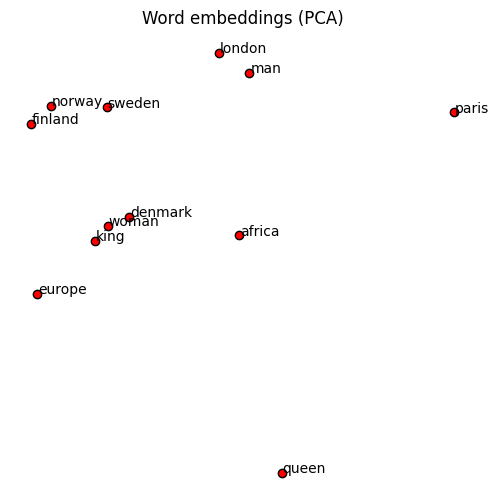

In [16]:
#pca
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

def plot_embeddings_pca(emb, inv_voc, words):
    # collect the embedding vector for each word into a matrix
    vectors = np.vstack([emb.weight[str_to_int[w]].cpu().detach().numpy() for w in words])

    # centre the vectors (subtract mean) so PCA works on variance not offset
    vectors -= vectors.mean(axis=0)

    # TruncatedSVD reduces the high-dimensional embedding vectors to 2D
    # so we can plot them on a flat scatter plot
    twodim = TruncatedSVD(n_components=2).fit_transform(vectors)

    plt.figure(figsize=(6, 6))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')
    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.02, y, word)
    plt.axis('off')
    plt.title('Word embeddings (PCA)')
    plt.savefig('a1_1/embeddings_pca.png', bbox_inches='tight')
    plt.show()


plot_words = ['sweden', 'denmark', 'norway', 'finland',
              'europe', 'africa', 'london', 'paris',
              'king', 'queen', 'man', 'woman']

# only plot words that are actually in the vocabulary
plot_words = [w for w in plot_words if w in str_to_int]
plot_embeddings_pca(model.embedding, int_to_str, plot_words)

Comments: Some things make sense. Groups sweden, finald, norway together. strange thouygh that queen is at bottom and not close to king. denmark-king-woman together and london-man